In [11]:
from torchvision.datasets import VOCDetection
dataset = VOCDetection(root='./data', year='2012', image_set='trainval', download=True)

KeyboardInterrupt: 

In [18]:
from torchvision.datasets import VOCDetection
dataset1 = VOCDetection(root='./data', year='2007', image_set='trainval', download=True)

100%|██████████| 460M/460M [00:18<00:00, 25.4MB/s] 


In [2]:
import os
import random
import xml.etree.ElementTree as ET

import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.ops import box_convert


VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat',
    'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
CLASS_TO_IDX = {cls: i for i, cls in enumerate(VOC_CLASSES)}


class VOCDetectionDataset(Dataset):
    def __init__(self, roots, image_set='trainval', img_size=224, augment=False):
        if isinstance(roots, str):
            roots = [roots]
        self.samples = [] 
        self.img_size = img_size
        self.augment = augment

        for root in roots:
            split_file = os.path.join(root, 'ImageSets/Main', f'{image_set}.txt')
            with open(split_file) as f:
                ids = [line.strip() for line in f.readlines()]
            self.samples.extend([(root, img_id) for img_id in ids])

        self.to_tensor_normalize = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        root, img_id = self.samples[idx]
        img_path = os.path.join(root, 'JPEGImages', f'{img_id}.jpg')
        ann_path = os.path.join(root, 'Annotations', f'{img_id}.xml')

        image = Image.open(img_path).convert('RGB')
        orig_w, orig_h = image.size
        boxes, labels = self._parse_annotation(ann_path, orig_w, orig_h)

        if self.augment:
            if random.random() < 0.5:
                image, boxes, labels = self._random_crop(image, boxes, labels)
            image, boxes = self._color_and_flip(image, boxes)

        image = TF.resize(image, (self.img_size, self.img_size))
        image = self.to_tensor_normalize(image)

        return image, boxes, labels

    def _parse_annotation(self, ann_path, orig_w, orig_h):
        tree = ET.parse(ann_path)
        root = tree.getroot()

        boxes, labels = [], []
        for obj in root.findall('object'):
            cls_name = obj.find('name').text
            if cls_name not in CLASS_TO_IDX:
                continue
            bbox = obj.find('bndbox')
            xmin = float(bbox.find('xmin').text)
            ymin = float(bbox.find('ymin').text)
            xmax = float(bbox.find('xmax').text)
            ymax = float(bbox.find('ymax').text)

            cx = ((xmin + xmax) / 2) / orig_w
            cy = ((ymin + ymax) / 2) / orig_h
            w = (xmax - xmin) / orig_w
            h = (ymax - ymin) / orig_h

            boxes.append([cx, cy, w, h])
            labels.append(CLASS_TO_IDX[cls_name])

        boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4), dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.long) if labels else torch.zeros((0,), dtype=torch.long)

        return boxes, labels

    def _random_crop(self, image, boxes, labels, min_scale=0.3, max_tries=10):
        if boxes.shape[0] == 0:
            return image, boxes, labels

        w, h = image.size

        for _ in range(max_tries):
            scale = random.uniform(min_scale, 1.0)
            crop_w, crop_h = max(1, int(w * scale)), max(1, int(h * scale))
            left = random.randint(0, w - crop_w)
            top = random.randint(0, h - crop_h)

            boxes_xyxy = box_convert(boxes, 'cxcywh', 'xyxy')
            boxes_xyxy[:, [0, 2]] *= w
            boxes_xyxy[:, [1, 3]] *= h

            new_boxes = boxes_xyxy.clone()
            new_boxes[:, [0, 2]] -= left
            new_boxes[:, [1, 3]] -= top
            new_boxes[:, [0, 2]] = new_boxes[:, [0, 2]].clamp(0, crop_w)
            new_boxes[:, [1, 3]] = new_boxes[:, [1, 3]].clamp(0, crop_h)

            box_w = new_boxes[:, 2] - new_boxes[:, 0]
            box_h = new_boxes[:, 3] - new_boxes[:, 1]
            valid = (box_w > 5) & (box_h > 5)

            if valid.sum() == 0:
                continue 

            image = TF.crop(image, top, left, crop_h, crop_w)

            kept_boxes = new_boxes[valid]
            kept_labels = labels[valid]

            kept_boxes_norm = box_convert(kept_boxes, 'xyxy', 'cxcywh')
            kept_boxes_norm[:, [0, 2]] /= crop_w
            kept_boxes_norm[:, [1, 3]] /= crop_h

            return image, kept_boxes_norm, kept_labels

        return image, boxes, labels

    def _color_and_flip(self, image, boxes):
        if random.random() < 0.5:
            image = TF.hflip(image)
            if boxes.shape[0] > 0:
                boxes = boxes.clone()
                boxes[:, 0] = 1.0 - boxes[:, 0]

        if random.random() < 0.5:
            image = TF.adjust_brightness(image, random.uniform(0.7, 1.3))
        if random.random() < 0.5:
            image = TF.adjust_contrast(image, random.uniform(0.7, 1.3))
        if random.random() < 0.5:
            image = TF.adjust_saturation(image, random.uniform(0.7, 1.3))

        return image, boxes


def collate_fn(batch):
    images, boxes, labels = zip(*batch)
    images = torch.stack(images)
    targets = [{'boxes': b, 'labels': l} for b, l in zip(boxes, labels)]
    return images, targets

In [3]:
import torch
from torch.utils.data import Subset
from torch.utils.data import DataLoader

roots = ['data/VOCdevkit/VOC2012', 'data/VOCdevkit/VOC2007']

full_dataset_aug = VOCDetectionDataset(roots=roots, image_set='trainval', augment=True)
full_dataset_plain = VOCDetectionDataset(roots=roots, image_set='trainval', augment=False)

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(full_dataset_aug), generator=generator).tolist()

train_size = int(0.7 * len(full_dataset_aug))
val_size = int(0.2 * len(full_dataset_aug))

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

train_dataset = Subset(full_dataset_aug, train_indices)
val_dataset = Subset(full_dataset_plain, val_indices)
test_dataset = Subset(full_dataset_plain, test_indices)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn, num_workers=4, pin_memory=True)

In [4]:
import os
from PIL import Image
from tqdm import tqdm

# Создаем папку для сохранения
output_dir = 'cvat_upload/train_images'
os.makedirs(output_dir, exist_ok=True)

# Получаем все изображения из train_dataset
for idx in tqdm(range(len(test_dataset))):
    # Получаем изображение (без трансформаций!)
    image, boxes, labels = test_dataset[idx]
    
    # Если это тензор, конвертируем в PIL Image
    if isinstance(image, torch.Tensor):
        # Обратная нормализация
        mean = torch.tensor([0.485, 0.456, 0.406])
        std = torch.tensor([0.229, 0.224, 0.225])
        image = image.cpu().detach()
        image = image * std[:, None, None] + mean[:, None, None]
        image = torch.clamp(image, 0, 1)
        image = image.permute(1, 2, 0).numpy() * 255
        image = Image.fromarray(image.astype('uint8'))
    
    # Сохраняем изображение
    image_path = os.path.join(output_dir, f'train_{idx:06d}.jpg')
    image.save(image_path)

 20%|██        | 333/1656 [00:01<00:06, 200.34it/s]


KeyboardInterrupt: 

In [4]:
from going_modular.msa_mlp import MultiheadSelfAttentionBlock, MLPBlock
from torch import nn

def inverse_sigmoid(x, eps=1e-5):
    x = x.clamp(min=eps, max=1 - eps)
    return torch.log(x / (1 - x))

class TransformerDecoderBlock(nn.Module):
    def __init__(self, embedding_dim=128,
    num_heads=4, mlp_size=512, mlp_dropout=0.1, attn_dropout=0):
        super().__init__()
        self.self_attn = MultiheadSelfAttentionBlock(
            embedding_dim=embedding_dim,
            num_heads=num_heads,
            attn_dropout=attn_dropout
        )
        self.cross_attn_norm = nn.LayerNorm(normalized_shape=embedding_dim)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=embedding_dim,
            num_heads=num_heads,
            dropout=attn_dropout,
            batch_first=True
        )

        self.mlp = MLPBlock(
            embedding_dim=embedding_dim,
            mlp_size=mlp_size,
            mlp_dropout=mlp_dropout)

    def forward(self, x, memory):
        x = self.self_attn(x) + x
        x_norm = self.cross_attn_norm(x)
        x = self.cross_attn(query=x_norm, key=memory, value=memory, need_weights=False)[0] + x
        x = self.mlp(x) + x
        return x


class TransfomerDecoder(nn.Module):
    def __init__(self,
                 num_layers=2,
                 embedding_dim=128,
                 num_heads=4,
                 mlp_size=512,
                 attn_dropout=0.1,
                 mlp_dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            TransformerDecoderBlock(
                embedding_dim=embedding_dim,
                num_heads=num_heads,
                mlp_size=mlp_size,
                attn_dropout=attn_dropout,
                mlp_dropout=mlp_dropout
            ) for _ in range(num_layers)
        ])

    def forward(self, x, memory):
        for layer in self.layers:
            x = layer(x, memory)
        return x




In [5]:
import sys
import os
from torch import nn
import torch

project_root = os.path.dirname(os.getcwd())
if not os.path.exists(os.path.join(project_root, 'going_modular')):
    project_root = os.getcwd()

modular_path = os.path.join(project_root, 'going_modular')
if modular_path not in sys.path:
    sys.path.insert(0, modular_path)

print(f"✅ Добавлен путь: {modular_path}")

✅ Добавлен путь: /home/morozzz/Desktop/detection/CNN/going_modular


In [6]:

from going_modular.resnetBlock import ResNetBlock
from going_modular.transformerBlock import ViT

class HybridDetectionModel(nn.Module):
    def __init__(self, in_channels=3, hidden_units=64, 
    num_transformer_layers=4,
    num_decoder_layers=4,
    embedding_dim=128,
    num_heads=4,
    mlp_size=512,
    num_classes=20,
    num_queries=18):
        super().__init__()
        self.cnn = ResNetBlock(use_high_res=False)
        self.projection = nn.Linear(self.cnn.out_channels, embedding_dim)
        self.encoder = ViT(num_patches=14*14,
            num_transformer_layers=num_transformer_layers,
            embedding_dim=embedding_dim,
            mlp_size=mlp_size,
            num_heads=num_heads,
            attn_dropout=0,
            mlp_dropout=0.1,
            embedding_dropout=0.1,
            num_classes=num_classes,
            use_cls_token=False)
        self.num_queries = num_queries
        self.query_embed = nn.Parameter(torch.rand(num_queries, embedding_dim) * 0.1)
        self.reference_points = nn.Linear(embedding_dim, 4)
        self.decoder = TransfomerDecoder(num_layers=num_decoder_layers,
        embedding_dim=embedding_dim,
        num_heads=num_heads,
        mlp_size=mlp_size,
        )
        self.class_head = nn.Sequential(
        nn.Dropout(p=0.15),
        nn.Linear(embedding_dim, num_classes + 1)
        )
        self.bbox_head = nn.Sequential(
        nn.Linear(embedding_dim, embedding_dim),
        nn.ReLU(),
        nn.Linear(embedding_dim, embedding_dim),
        nn.ReLU(),
        nn.Linear(embedding_dim, 4),
    )

    def forward(self, x):
        x = self.cnn(x)
        x = x.flatten(2)
        x = x.permute(0, 2, 1)
        x = self.projection(x)
        B = x.shape[0]
        memory = self.encoder(x)
        queries = self.query_embed.unsqueeze(0).repeat(B, 1, 1)
        reference = torch.sigmoid(self.reference_points(queries))
        decoded = queries
        aux_outputs = []
        final_logits = None
        final_boxes = None
        for i, layer in enumerate(self.decoder.layers):
            decoded = layer(decoded, memory)

            box_delta = self.bbox_head(decoded)
            reference_logit = inverse_sigmoid(reference) + box_delta
            reference = torch.sigmoid(reference_logit)
 
            pred_logits = self.class_head(decoded)
 
            if i < len(self.decoder.layers) - 1:
                aux_outputs.append({'pred_logits': pred_logits, 'pred_boxes': reference})
            else:
                final_logits = pred_logits
                final_boxes = reference

        return {
            'pred_logits': final_logits,
            'pred_boxes': final_boxes,
            'aux_outputs': aux_outputs
        }






In [7]:
from torchvision.ops import box_convert, generalized_box_iou, generalized_box_iou_loss
from scipy.optimize import linear_sum_assignment
import torch.nn.functional as F

class HungrianMatcher(nn.Module):
    def __init__(self, cost_class=1, cost_bbox=5, cost_giou=2):
        super().__init__()
        self.cost_class = cost_class
        self.cost_bbox = cost_bbox
        self.cost_giou = cost_giou

    @torch.no_grad()
    def forward(self, outputs, targets):
        B, num_queries = outputs['pred_logits'].shape[:2]
        indices = []
        for b in range(B):
            out_prob = outputs['pred_logits'][b].softmax(-1)
            out_bbox = outputs['pred_boxes'][b]

            tgt_ids = targets[b]['labels']
            tgt_bbox = targets[b]['boxes']

            if len(tgt_ids) == 0:
                indices.append((torch.tensor([], dtype=torch.long), torch.tensor([], dtype=torch.long)))
                continue

            cost_class = -out_prob[:, tgt_ids]
            cost_bbox = torch.cdist(out_bbox, tgt_bbox, p=1)
            out_bbox_xyxy = box_convert(out_bbox, 'cxcywh', 'xyxy')
            tgt_bbox_xyxy = box_convert(tgt_bbox, 'cxcywh', 'xyxy')
            giou_matrix = generalized_box_iou(out_bbox_xyxy, tgt_bbox_xyxy)
            cost_giou = -giou_matrix
           
            C = self.cost_bbox * cost_bbox + self.cost_class * cost_class + self.cost_giou * cost_giou
            row_ind, col_ind = linear_sum_assignment(C.cpu())
            indices.append((torch.as_tensor(row_ind), torch.as_tensor(col_ind)))
        return indices

def compute_single_layer_loss(pred_logits, pred_boxes, targets, matcher, num_classes, eos_coef=0.1):
    outputs_for_matcher = {'pred_logits': pred_logits, 'pred_boxes': pred_boxes}
    indices = matcher(outputs_for_matcher, targets)
    device = pred_logits.device
 
    target_classes = torch.full(pred_logits.shape[:2], num_classes, dtype=torch.long, device=device)
    bbox_loss = 0.0
    giou_loss = 0.0
    num_boxes = 0
 
    for b, (query_idx, tgt_idx) in enumerate(indices):
        if len(tgt_idx) == 0:
            continue
        target_classes[b, query_idx] = targets[b]['labels'][tgt_idx]
 
        pb = pred_boxes[b, query_idx]
        tb = targets[b]['boxes'][tgt_idx]
 
        bbox_loss += F.l1_loss(pb, tb, reduction='sum')
        pred_xyxy = box_convert(pb, 'cxcywh', 'xyxy')
        tgt_xyxy = box_convert(tb, 'cxcywh', 'xyxy')
        giou_loss += generalized_box_iou_loss(pred_xyxy, tgt_xyxy, reduction='sum')
        num_boxes += len(tgt_idx)
 
    num_boxes = max(num_boxes, 1)
 
    class_weights = torch.ones(num_classes + 1, device=device)
    class_weights[-1] = eos_coef
 
    class_loss = F.cross_entropy(
        pred_logits.reshape(-1, num_classes + 1),
        target_classes.reshape(-1),
        weight=class_weights
    )
 
    bbox_loss_norm = bbox_loss / num_boxes
    giou_loss_norm = giou_loss / num_boxes
    total = class_loss + bbox_loss_norm * 5 + giou_loss_norm * 2
 
    return total, indices, class_loss, bbox_loss_norm, giou_loss_norm

def compute_loss(outputs, targets, matcher, num_classes, eos_coef=0.1, aux_weight=0.5):
    total_loss, indices, class_loss, bbox_loss, giou_loss = compute_single_layer_loss(
        outputs['pred_logits'], outputs['pred_boxes'], targets, matcher, num_classes, eos_coef
    )
 
    aux_outputs = outputs.get('aux_outputs', [])
    for aux in aux_outputs:
        aux_total, _, _, _, _ = compute_single_layer_loss(
            aux['pred_logits'], aux['pred_boxes'], targets, matcher, num_classes, eos_coef
        )
        total_loss = total_loss + aux_weight * aux_total


    return total_loss, indices, class_loss, bbox_loss, giou_loss


def compute_accuracy(outputs, targets, indices):
    correct, total = 0, 0
    for b, (query_idx, tgt_idx) in enumerate(indices):
        if len(tgt_idx) == 0:
            continue
        pred_classes = outputs['pred_logits'][b, query_idx].argmax(dim=-1)
        true_classes = targets[b]['labels'][tgt_idx]
        correct += (pred_classes == true_classes).sum().item()
        total += len(tgt_idx)
    return correct, total


def update_map_metric(map_metric, outputs, targets, conf_threshold=0.5):
    probs = outputs['pred_logits'].softmax(-1)
    scores, labels = probs[..., :-1].max(-1)
    boxes_xyxy = box_convert(outputs['pred_boxes'], 'cxcywh', 'xyxy')
 
    preds, gts = [], []
    for b in range(len(targets)):
        keep = scores[b] > conf_threshold
        preds.append({
            'boxes': boxes_xyxy[b][keep].cpu(),
            'scores': scores[b][keep].cpu(),
            'labels': labels[b][keep].cpu()
        })
        gts.append({
            'boxes': box_convert(targets[b]['boxes'], 'cxcywh', 'xyxy').cpu(),
            'labels': targets[b]['labels'].cpu()
        })
    map_metric.update(preds, gts)




In [8]:
from torchmetrics.detection import MeanAveragePrecision
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter

scaler = torch.amp.GradScaler('cuda')

@torch.no_grad()
def val_step(model, dataloader, num_classes, matcher,
    device, conf_threshold=0.5, compute_map=True):
    model.eval()
    total_loss = 0
    localization_loss_sum = 0
    correct, total = 0, 0
    map_metrics = MeanAveragePrecision(box_format='xyxy')
    for images, targets in dataloader:
        images = images.to(device)
        targets = [{'boxes': t['boxes'].to(device),
         'labels': t['labels'].to(device)} for t in targets]
        outputs = model(images)
        loss, indices, class_loss, bbox_loss, giou_loss = compute_loss(outputs, targets, matcher, num_classes)
 
        total_loss += loss.item()
        localization_loss_sum += bbox_loss + giou_loss
        c, t = compute_accuracy(outputs, targets, indices)
        correct += c
        total += t

        if compute_map:
            update_map_metric(map_metrics, outputs, targets, conf_threshold)
    
    avg_loss = total_loss / len(dataloader)
    avg_localization_loss = localization_loss_sum / len(dataloader)
    accuracy = correct / total if total > 0 else 0.0
    map_result = map_metrics.compute() if compute_map else None
 
    return avg_loss, accuracy, map_result, class_loss, bbox_loss, giou_loss, avg_localization_loss


def train_step(model, dataloader, optimizer, num_classes, matcher,
    device):
    model.train()
    total_loss = 0
    correct, total = 0, 0
    for images, targets in dataloader:
        images = images.to(device)
        targets = [{'boxes': t['boxes'].to(device),
         'labels': t['labels'].to(device)} for t in targets]
        outputs = model(images)
        loss, indices, class_loss, bbox_loss, giou_loss = compute_loss(outputs, targets, matcher, num_classes)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):  # эта часть вычисляется в float16 где возможно
            outputs = model(images)
            loss, indices, class_loss, bbox_loss, giou_loss = compute_loss(outputs, targets, matcher, num_classes)

        # GradScaler нужен, чтобы избежать потери маленьких градиентов при float16
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        c, t = compute_accuracy(outputs, targets, indices)
        correct += c
        total += t

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total if total > 0 else 0.0
    return avg_loss, accuracy, class_loss, bbox_loss, giou_loss


def train(model, train_dataloader, val_dataloader, matcher,
    num_classes, epochs=50, lr=1e-4, patience=10,
    map_every_n_epochs=5, device=None):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    bbox_decoder_params = list(model.decoder.parameters()) + list(model.bbox_head.parameters())
    bbox_decoder_param_ids = {id(p) for p in bbox_decoder_params}
    other_params = [p for p in model.parameters() if p.requires_grad and id(p) not in bbox_decoder_param_ids]
    bbox_decoder_params = [p for p in bbox_decoder_params if p.requires_grad]
    optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=0.05
)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
    )
    best_val_loss = float('inf')
    epochs_no_improve = 0

    writer = SummaryWriter()

    results = {"train_loss": [],
               "train_acc": [],
               "val_loss": [],
               "val_acc": [],
               'train_class_loss': [],
               'train_bbox_loss': [],
               'train_giou_loss': [],
               'val_class_loss': [],
               'val_bbox_loss': [],
               'val_giou_loss': [],
               'lr': []
    }
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc, train_class_loss, train_bbox_loss, train_giou_loss = train_step(
            model=model,
            dataloader=train_dataloader,
            optimizer=optimizer,
            num_classes=num_classes,
            matcher=matcher,
            device=device
        )

        compute_map = ((epoch + 1) % map_every_n_epochs == 0) or (epoch == epochs - 1)
        val_loss, val_acc, val_map , val_class_loss, val_bbox_loss, val_giou_loss, val_localization_loss = val_step(
            model=model,
            dataloader=val_dataloader,
            num_classes=num_classes,
            matcher=matcher,
            device=device,
            conf_threshold=0.5,
            compute_map=compute_map
        )

        scheduler.step(val_localization_loss)
        current_lr = optimizer.param_groups[0]['lr']

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)
        results['train_class_loss'].append(train_class_loss)
        results['train_bbox_loss'].append(train_bbox_loss)
        results['train_giou_loss'].append(train_giou_loss)
        results['val_class_loss'].append(val_class_loss)
        results['val_bbox_loss'].append(val_bbox_loss)
        results['val_giou_loss'].append(val_giou_loss)
        results['lr'].append(current_lr)

        if writer:
            writer.add_scalars(main_tag="Loss", 
                                tag_scalar_dict={"train_loss": train_loss,
                                                    "val_loss": val_loss},
                                global_step=epoch)

            writer.add_scalars(main_tag="Accuracy", 
                                tag_scalar_dict={"train_acc": train_acc,
                                                    "val_acc": val_acc}, 
                                global_step=epoch)

            writer.add_scalars(main_tag="Class loss", 
                                tag_scalar_dict={"train_class_loss": train_class_loss,
                                                    "val_class_loss": val_class_loss}, 
                                global_step=epoch)

            writer.add_scalars(main_tag="Bbox loss", 
                                tag_scalar_dict={"train_bbox_loss": train_bbox_loss,
                                                    "val_bbox_loss": val_bbox_loss}, 
                                global_step=epoch)

            writer.add_scalars(main_tag="Giou loss", 
                                tag_scalar_dict={"train_giou_loss": train_giou_loss,
                                                    "val_giou_loss": val_giou_loss}, 
                                global_step=epoch)
            writer.close()

        log = (f"Epoch {epoch+1}/{epochs} | "
               f"train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} | "
               f"val_loss: {val_loss:.4f} val_acc: {val_acc:.4f} | lr: {current_lr}")
        if val_map:
            log += f" | val_mAP: {val_map['map']:.4f} val_mAP@50: {val_map['map_50']:.4f}"
        print(log)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'moredecoder.pth')
            print(f"  → новый лучший чекпоинт (val_loss={val_loss:.4f})")
        else:
            epochs_no_improve += 1
 
        if epochs_no_improve >= patience:
            print(f"Останавливаемся: нет улучшений {patience} эпох подряд")
            break
 
    return results


   




In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HybridDetectionModel()
model.to(device)
matcher = HungrianMatcher()
results = train(model=model,
train_dataloader=train_loader,
val_dataloader=val_loader,
matcher=matcher,
num_classes=20)



  2%|▏         | 1/50 [03:26<2:48:30, 206.34s/it]

Epoch 1/50 | train_loss: 13.4394 train_acc: 0.3403 | val_loss: 11.0227 val_acc: 0.4674 | lr: 0.0001
  → новый лучший чекпоинт (val_loss=11.0227)


  4%|▍         | 2/50 [06:52<2:44:53, 206.12s/it]

Epoch 2/50 | train_loss: 10.4035 train_acc: 0.4755 | val_loss: 10.2868 val_acc: 0.5534 | lr: 0.0001
  → новый лучший чекпоинт (val_loss=10.2868)


  6%|▌         | 3/50 [10:18<2:41:32, 206.23s/it]

...

Epoch 36/50 | train_loss: 5.7741 train_acc: 0.7866 | val_loss: 7.8476 val_acc: 0.6164 | lr: 0.0001


 74%|███████▍  | 37/50 [2:08:30<46:28, 214.51s/it]

Epoch 37/50 | train_loss: 5.8615 train_acc: 0.7803 | val_loss: 7.7212 val_acc: 0.6748 | lr: 0.0001


 74%|███████▍  | 37/50 [2:11:53<46:20, 213.88s/it]

Epoch 38/50 | train_loss: 5.6722 train_acc: 0.7943 | val_loss: 7.6516 val_acc: 0.6508 | lr: 0.0001
Останавливаемся: нет улучшений 10 эпох подряд


In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HybridDetectionModel()
model.to(device)
matcher = HungrianMatcher()

# --- фильтрация несовместимых по форме ключей перед загрузкой ---
checkpoint = torch.load('newloss.pth')
model_dict = model.state_dict()

filtered_checkpoint = {
    k: v for k, v in checkpoint.items()
    if k.startswith('cnn.') and v.shape == model_dict[k].shape and k in model_dict
}
skipped = [k for k in checkpoint if k not in filtered_checkpoint]
print(f"Перенесено весов: {len(filtered_checkpoint)}, сброшено: {len(skipped)}")

model.load_state_dict(filtered_checkpoint, strict=False)
results = train(model=model,
train_dataloader=train_loader,
val_dataloader=val_loader,
matcher=matcher,
num_classes=20)

Перенесено весов: 120, сброшено: 98


  2%|▏         | 1/50 [02:14<1:50:02, 134.74s/it]

Epoch 1/50 | train_loss: 8.2206 train_acc: 0.3447 | val_loss: 6.8845 val_acc: 0.4875 | lr: 0.0001
  → новый лучший чекпоинт (val_loss=6.8845)


  2%|▏         | 1/50 [03:46<3:04:46, 226.26s/it]


KeyboardInterrupt: 

In [16]:
import torch
import numpy as np
from torchvision.ops import box_convert, box_iou, nms
import matplotlib.pyplot as plt

VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat',
    'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

@torch.no_grad()
def build_confusion_matrix(model, dataloader, num_classes, device,
                            conf_threshold=0.5, iou_threshold=0.5, nms_threshold=0.5):
    model.eval()
    # +1 строка/столбец — "background" (для false positive / false negative)
    matrix = np.zeros((num_classes + 1, num_classes + 1), dtype=int)
    background_idx = num_classes

    for images, targets in dataloader:
        images = images.to(device)
        outputs = model(images)

        probs = outputs['pred_logits'].softmax(-1)
        scores, labels = probs[..., :-1].max(-1)  # без no-object класса
        boxes_xyxy = box_convert(outputs['pred_boxes'], 'cxcywh', 'xyxy')

        for b in range(len(targets)):
            # --- фильтрация по confidence + NMS, как в inference.py ---
            keep_conf = scores[b] > conf_threshold
            pred_boxes = boxes_xyxy[b][keep_conf]
            pred_labels = labels[b][keep_conf]
            pred_scores = scores[b][keep_conf]

            final_boxes, final_labels = [], []
            for cls_id in pred_labels.unique():
                cls_mask = pred_labels == cls_id
                cls_boxes = pred_boxes[cls_mask]
                cls_scores = pred_scores[cls_mask]
                keep_idx = nms(cls_boxes, cls_scores, iou_threshold=nms_threshold)
                final_boxes.append(cls_boxes[keep_idx])
                final_labels.append(pred_labels[cls_mask][keep_idx])

            if final_boxes:
                pred_boxes = torch.cat(final_boxes)
                pred_labels = torch.cat(final_labels)
            else:
                pred_boxes = torch.zeros((0, 4))
                pred_labels = torch.zeros((0,), dtype=torch.long)

            gt_boxes = box_convert(targets[b]['boxes'], 'cxcywh', 'xyxy').to(device)
            gt_labels = targets[b]['labels'].to(device)

            # --- сопоставление предсказаний с ground truth через IoU ---
            matched_gt = set()
            matched_pred = set()

            if len(pred_boxes) > 0 and len(gt_boxes) > 0:
                iou_matrix = box_iou(pred_boxes, gt_boxes)  # [num_pred, num_gt]

                # жадное сопоставление: берём пары с наибольшим IoU по убыванию
                pairs = []
                for i in range(iou_matrix.shape[0]):
                    for j in range(iou_matrix.shape[1]):
                        if iou_matrix[i, j] > iou_threshold:
                            pairs.append((iou_matrix[i, j].item(), i, j))
                pairs.sort(reverse=True)  # сортируем по убыванию IoU

                for iou_val, i, j in pairs:
                    if i in matched_pred or j in matched_gt:
                        continue  # предсказание или GT уже использованы
                    matched_pred.add(i)
                    matched_gt.add(j)
                    true_cls = gt_labels[j].item()
                    pred_cls = pred_labels[i].item()
                    matrix[true_cls, pred_cls] += 1

            # false positives — предсказания без пары
            for i in range(len(pred_boxes)):
                if i not in matched_pred:
                    pred_cls = pred_labels[i].item()
                    matrix[background_idx, pred_cls] += 1

            # false negatives — объекты, которые модель пропустила
            for j in range(len(gt_boxes)):
                if j not in matched_gt:
                    true_cls = gt_labels[j].item()
                    matrix[true_cls, background_idx] += 1

    return matrix


def plot_confusion_matrix(matrix, class_names):
    labels = class_names + ['background']
    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(matrix, cmap='Blues')

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Реальный класс')
    ax.set_title('Confusion Matrix')

    # подписи чисел внутри ячеек
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            if matrix[i, j] > 0:
                ax.text(j, i, str(matrix[i, j]), ha='center', va='center',
                         color='white' if matrix[i, j] > matrix.max()/2 else 'black', fontsize=7)

    plt.colorbar(im)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()

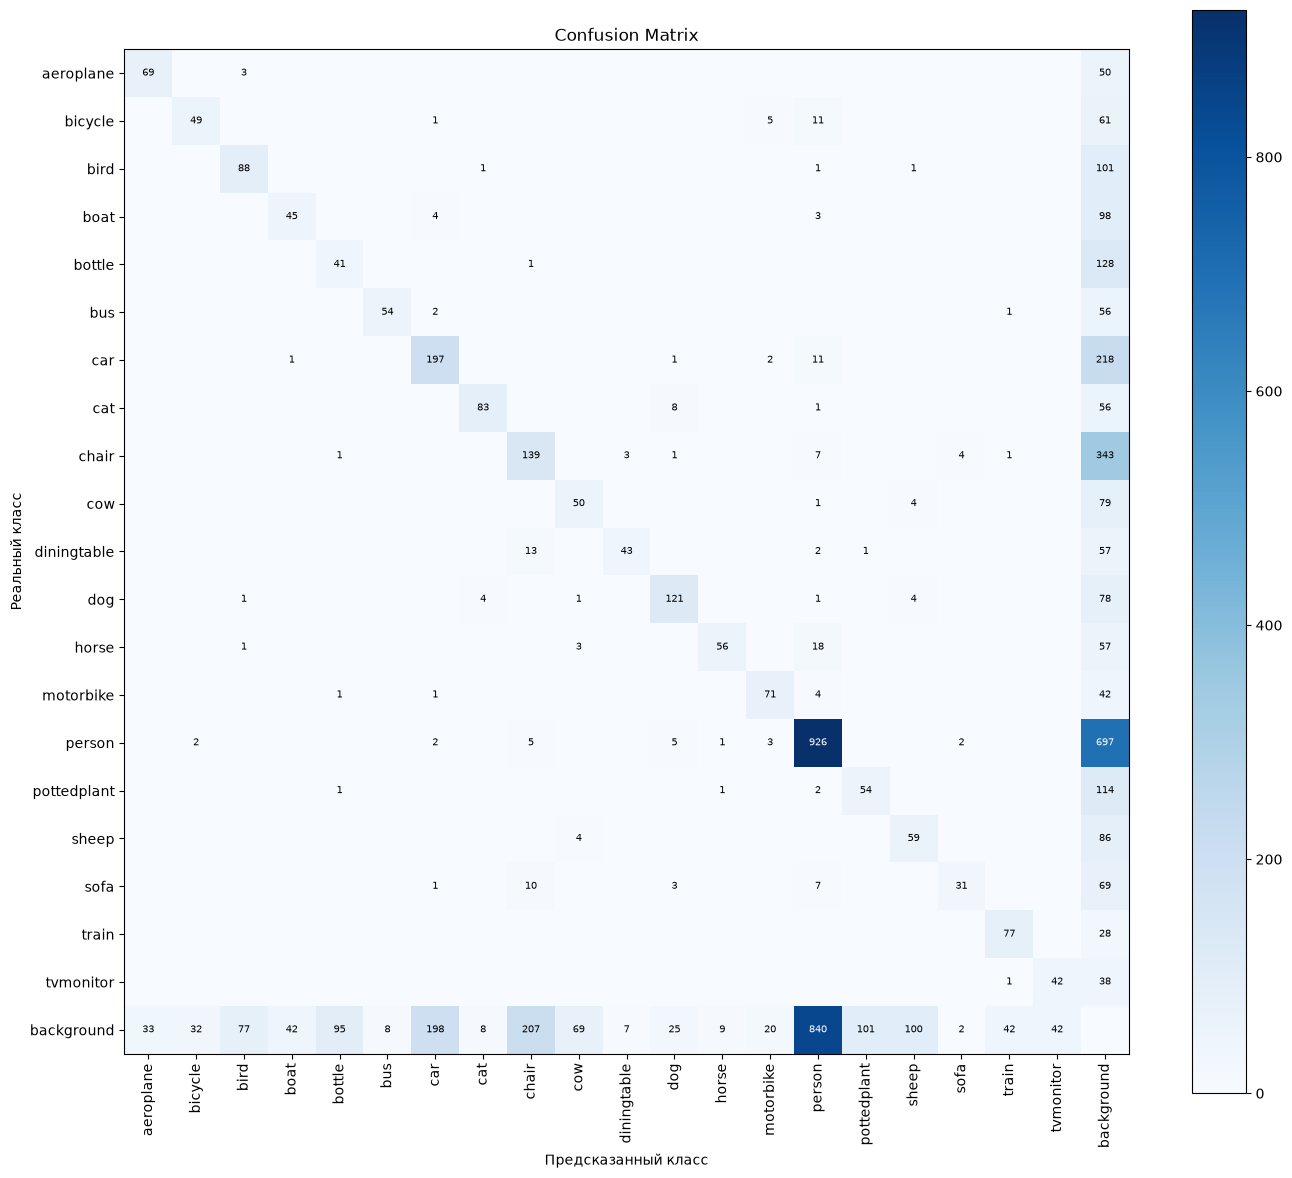

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HybridDetectionModel(num_classes=20).to(device)
model.load_state_dict(torch.load('moredecoder.pth', map_location=device))

matrix = build_confusion_matrix(model, test_loader, num_classes=20, device=device,
                                  conf_threshold=0.7, iou_threshold=0.3)
plot_confusion_matrix(matrix, VOC_CLASSES)

In [21]:
def per_class_metrics(matrix, class_names):
    num_classes = len(class_names)
    for i, name in enumerate(class_names):
        tp = matrix[i, i]
        fn = matrix[i, :].sum() - tp  # включая background в конце строки
        fp = matrix[:, i].sum() - tp  # включая background в конце столбца
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        print(f"{name:15s} recall={recall:.2f} precision={precision:.2f}")

per_class_metrics(matrix, VOC_CLASSES)

aeroplane       recall=0.57 precision=0.68
bicycle         recall=0.39 precision=0.59
bird            recall=0.46 precision=0.52
boat            recall=0.30 precision=0.51
bottle          recall=0.24 precision=0.29
bus             recall=0.48 precision=0.87
car             recall=0.46 precision=0.49
cat             recall=0.56 precision=0.86
chair           recall=0.28 precision=0.37
cow             recall=0.37 precision=0.39
diningtable     recall=0.37 precision=0.81
dog             recall=0.58 precision=0.74
horse           recall=0.41 precision=0.84
motorbike       recall=0.60 precision=0.70
person          recall=0.56 precision=0.50
pottedplant     recall=0.31 precision=0.35
sheep           recall=0.40 precision=0.35
sofa            recall=0.26 precision=0.79
train           recall=0.73 precision=0.63
tvmonitor       recall=0.52 precision=0.50
